# 레이블 없는 데이터를 활용한 사전 훈련 목차
* [Chapter 1 텍스트 생성 모델 평가하기](#chapter1)
* [Chapter 2 LLM 훈련하기](#chapter2)
* [Chapter 3 LLM 무작위성을 제어하기 위한 디코딩 전략](#chapter3)
* [Chapter 4 파이토치로 모델 로드하고 저장하기](#chapter4)
* [Chapter 5 오픈AI에서 사전 훈련된 가중치 로드하기](#chapter5)

## Chapter 1 텍스트 생성 모델 평가하기 <a class="anchor" id="chapter1"></a>
1. 텍스트 생성 과정을 간략히 정리한 후 텍스트 생성을 위해 LLM을 준비한다.

2. 생성된 텍스트의 품질을 평가하는 기본적인 방법을 소개한다.

    ![구현 순서](image/05-01-process2.png)

3. GPT를 사용해 텍스트 생성하기
   - LLM을 준비하고 텍스트 생성 과정을 간단하게 복습한다.

      ![구현 순서2](image/05-01-processTxt2.png)

In [1]:
# 깃허브에서 previous_chapters.py 파일을 다운로드합니다.
!wget https://bit.ly/3HlFmc8 -O previous_chapters.py

--2025-10-21 14:55:48--  https://bit.ly/3HlFmc8
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/previous_chapters.py [following]
--2025-10-21 14:55:48--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9905 (9.7K) [text/plain]
Saving to: ‘previous_chapters.py’

previous_chapters.p 100%[===================>]   9.67K  --.-KB/s    in 0s      

2025-10-21 14:55:48 (64.2 MB/s) - ‘previous_chapter

In [1]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257, # GPT-2 BPE 토크나이저의 어휘 크기
    "context_length": 256, # 모델 훈련에 필요한 계산 자원을 절감하기 위해 문맥 길이(context_length)를 256 토큰으로 줄인다.
    "emb_dim": 768, 
    "n_heads": 12, # 12개의 어텐션 헤드
    "n_layers": 12, # 12개의 트랜스포머 블록
    "drop_rate": 0.1, # 드롭아웃 확률 - 요즘에는 드롭아웃을 사용하지 않고 LLM을 훈련하는 경우가 많다.
    "qkv_bias": False, # 최신 LLM은 (초기 GPT 모델과 달리) 쿼리, 키, 값 행렬을 위한 nn.Linear 층에서 편향 벡터를 사용하지 않는다.
}

torch.manual_seed(123) # 재현성을 위해 시드 설정
model = GPTModel(GPT_CONFIG_124M) # 모델 초기화
model.eval() # 평가 모드로 전환

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=76

In [2]:
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # 배치 차원을 삭제합니다
    return tokenizer.decode(flat.tolist())




In [3]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

4. 텍스트 생성 손실 계산하기
    - 데이터를 로드하는 방법과 generate_text_simple 함수로 텍스트를 생성하는 방법을 간단히 정리한다.   
    - generate_text_simple이 내부적으로 수행하는 작업니다.
    - 모델이 아직 훈련을 하지 않아 타킷 토큰과 생성된 토큰이 거의 일치하지 않는다.

        ![간단 정리](image/05-01-processTxt4.png)
        

In [4]:
# 두 개의 입력
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

# 두 개의 타깃
#   - 타킷은 한 위치 앞으로 이동한 입력이다
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [5]:
# 입력을 모델에 주입하고 각각 3개의 토큰으로 구성된 로짓 벡터를 계산한다.
with torch.no_grad(): # 평가 모드에서는 그래디언트를 계산하지 않는다.
    logits = model(inputs)
    
probas = torch.softmax(logits, dim=-1) # 로짓을 확률로 변환한다.
# 2: 배치 크기, 3: 시퀀스 길이, 50257: 어휘 크기
print("probas shape:", probas.shape) # (2, 3, 50257)

probas shape: torch.Size([2, 3, 50257])


In [14]:
# softmax 함수로 로짓을 확률로 변환한 후에 이 확률 점수를 텍스트로 다시 변환
token_ids = torch.argmax(probas, dim=-1, keepdim=True) # 가장 높은 확률을 갖는 토큰을 선택
print("생성된 토큰 IDs:\n", token_ids)

# 
print(f"첫 번째 샘플의 타깃: {token_ids_to_text(targets[0], tokenizer)}")
print(f"첫 번째 샘플의 타깃: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")



생성된 토큰 IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])
첫 번째 샘플의 타깃:  effort moves you
첫 번째 샘플의 타깃:  Armed heNetflix


5. 모델 훈련의 목적은 정답 타깃 ID에 해당하는 인덱스의 소프트맥스 확률을 증가시키는 것이다.
    - 다른 토큰에 비해 정답 토큰의 확률을 높여야한다
    - 토큰 ID에 대해 모델이 높은 값을 출력하도록 가중치를 높여야한다.
    - 가중치 업데이트는 심층 신경망 기법인 역전파 과정을 통해 수행된다.
    - 역전파에는 모델의 예측과 실제 출력 사이의 차이를 계산하는 손실함수가 필요하다
    - 손실 함수는 모델의 예측 값과 타깃 값이 얼마나 떨어져있는지를 측정한다.

    ![훈련 목적](image/05-01-target2.png)

6. 두 샘플의 확률 점수에 대한 손실을 계산한다.
    - 모델의 가중치를 업데이트하여 평균 로그 확률이 가능한 0에 가깝게 만드는 것이 목표이다.
    - 일반적인 딥러닝에서는 음의 평균 로그 확률을 0으로 만든다.
       - 평균 로그 확률에 -1을 곱한다.

        ![손실계산](image/05-01-loss2.png)    

7. 크로스 엔트로피(cross-entropy) 손실 함수
    - 딥러닝에서 음수를 양수로 바꾼다.
    - 파이토치에서는 nn.CrossEntropyLoss() 클래스로 제공된다.
    - 두 확률 분포 사이의 차이를 계산한다.
    - 모델이 생성한 토큰 확률이 주어졌을 때 타깃 토큰에 대한 음의 평균 로그 확률과 비슷하다.

8. 혼잡도(perplexity)
    - 혼잡도는 모델이 다음 토큰을 얼마나 잘 예측하는지를 나타내는 지표이다.
    - 혼잡도는 모델의 예측이 얼마나 불확실한지를 나타낸다.
    - 혼잡도가 낮을수록 모델의 예측이 더 확실하다.
    - 혼잡도는 음의 평균 로그 확률의 지수 함수로 정의된다.
    - 혼잡도가 낮을수록 모델의 성능이 좋다.

    

In [7]:
# 손실 계산 1 ~ 3 단계
#   - 로짓  -> 확률 -> 타깃 토큰 확률
text_idx = 0
target_probas_1 =  probas[text_idx, [0, 1, 2], targets[text_idx]]
print("첫 번째 샘플의 타깃 토큰에 대한 초기 확률:", target_probas_1)

text_idx = 1
target_probas_2 =  probas[text_idx, [0, 1, 2], targets[text_idx]]
print("두 번째 샘플의 타깃 토큰에 대한 초기 확률:", target_probas_2)

첫 번째 샘플의 타깃 토큰에 대한 초기 확률: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
두 번째 샘플의 타깃 토큰에 대한 초기 확률: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [8]:
# 손실 계산 4 단계
#   - 로그 확률
# 타깃 토큰에 대한 음의 로그 확률을 계산한다.
#   - 로그 확률은 매우 작은 확률 값을 더 안정적으로 다룰 수 있게 해준다.
#   - 로그 확률은 확률 값이 0에 가까워질수록 더 큰 음수 값을 갖게 된다.
#   - 로그 확률을 최대화하는 것은 확률을 최대화하는 것과 같다.
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print("타깃 토큰에 대한 로그 확률:", log_probas)

타깃 토큰에 대한 로그 확률: tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [9]:
# 손실 계산 5 단계
#   - 평균 로그 확률
avg_log_proba = torch.mean(log_probas)
print("평균 로그 확률:", avg_log_proba)

neg_avg_log_proba = avg_log_proba * -1
print("음의 평균 로그 확률(손실 값):", neg_avg_log_proba)

평균 로그 확률: tensor(-10.7940)
음의 평균 로그 확률(손실 값): tensor(10.7940)


In [10]:
# 로짓과 타깃 텐서의 크기 확인
print("로짓의 크기:", logits.shape)  # (2, 3, 50257) - 배치 크기 2, 시퀀스 길이 3, 어휘 크기 50257
print("타깃의 크기:", targets.shape)  # (2, 3) - 배치 크기 2, 시퀀스 길이 3

로짓의 크기: torch.Size([2, 3, 50257])
타깃의 크기: torch.Size([2, 3])


In [11]:
# 파이토치의 크로스 엔트로피 손실 함수를 위해 처음 두 차원을 결합하여 두 텐서를 펼친다.
logits_flat = logits.flatten(0, 1)
print("펼쳐진 로짓의 크기:", logits_flat.shape)  # (6, 50257) - 배치 크기 * 시퀀스 길이, 어휘 크기

targets_flat = targets.flatten()
print("펼쳐진 타깃의 크기:", targets_flat.shape)  # (6,) - 배치 크기 * 시퀀스 길이

펼쳐진 로짓의 크기: torch.Size([6, 50257])
펼쳐진 타깃의 크기: torch.Size([6])


In [12]:
inputs2 = torch.tensor(
  [
      [[1,1,1,1,1],[2,2,2,2,2],[3,3,3,3,3]], 
      [[4,4,4,4,4],[5,5,5,5,5],[6,6,6,6,6]], 
      [[7,7,7,7,7],[8,8,8,8,8],[9,9,9,9,9]], 
      [[10,10,10,10,10],[11,11,11,11,11],[12,12,12,12,12]], 
      [[13,13,13,13,13],[14,14,14,14,14],[15,15,15,15,15]], 
      [[16,16,16,16,16],[17,17,17,17,17],[18,18,18,18,18]]  
  ]
)

print("inputs2:", inputs2.shape)

inputs3 = inputs2.flatten(0, 1)
print("inputs3:", inputs3)
print("inputs3:", inputs3.shape)

inputs2: torch.Size([6, 3, 5])
inputs3: tensor([[ 1,  1,  1,  1,  1],
        [ 2,  2,  2,  2,  2],
        [ 3,  3,  3,  3,  3],
        [ 4,  4,  4,  4,  4],
        [ 5,  5,  5,  5,  5],
        [ 6,  6,  6,  6,  6],
        [ 7,  7,  7,  7,  7],
        [ 8,  8,  8,  8,  8],
        [ 9,  9,  9,  9,  9],
        [10, 10, 10, 10, 10],
        [11, 11, 11, 11, 11],
        [12, 12, 12, 12, 12],
        [13, 13, 13, 13, 13],
        [14, 14, 14, 14, 14],
        [15, 15, 15, 15, 15],
        [16, 16, 16, 16, 16],
        [17, 17, 17, 17, 17],
        [18, 18, 18, 18, 18]])
inputs3: torch.Size([18, 5])


In [13]:
# 파이토치 크로스 엔트로피 손실 함수 사용
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print("파이토치 크로스 엔트로피 손실 함수 값:", loss)

# 혼잡도 (perplexity) 계산
perplexity = torch.exp(loss)
# 48,725개의 토큰 중에 어떤 것을 사용할 지 불확살하다.
print("혼잡도 (perplexity):", perplexity)

파이토치 크로스 엔트로피 손실 함수 값: tensor(10.7940)
혼잡도 (perplexity): tensor(48725.8203)


9. 훈련 세트와 검증 세트의 손실 계산하기
    - LLM을 훈련하는 데 사용할 훈련 데이터 셋과 검증 데이터 셋을 준비한다.
    - 텍스트 데이터 셋으로 이디스 워튼의 단편 소설 'The Verdict'를 사용한다.
        - 적절한 GPU가 없는 랩탑 컴퓨터에서 몇 분 안에 코드 예제가 실행되어야 합니다.
        - 교육 목적을 위해 훈련이 비교적 빨리 끝나야 합니다(몇 주가 아니라 몇 분 만에).
        - 사용 권리를 위반하지 않으며 깃허브 저장소에 저장할 수 있는 크기의 공개된 텍스트를 사용해야 합니다.
    - 데이터셋을 훈련 세트와 검증 세트로 나눈다.

        ![데이터셋](image/05-01-data2.png)  

In [15]:
file_path = 'the-verdict.txt'
with open(file_path, 'r', encoding='utf-8') as f:
    text_data = f.read()
    
total_characters = len(text_data)
print("총 문자 수:", total_characters)

total_tokens = len(tokenizer.encode(text_data))
print("총 토큰 수:", total_tokens)

총 문자 수: 20479
총 토큰 수: 5145


In [16]:
# 훈련 데이터 셋 90%, 검증 데이터 셋 10%로 분할
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [17]:
from previous_chapters import create_dataloader_v1

# 훈련 세트 비율
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [18]:
# 유효성 검사
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("훈련 데이터 로더에 토큰이 충분하지 않습니다. "
          "`GPT_CONFIG_124M['context_length']`를 낮추거나 "
          "`training_ratio`를 증가시키세요.")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("훈련 데이터 로더에 토큰이 충분하지 않습니다. "
          "`GPT_CONFIG_124M['context_length']`를 낮추거나 "
          "`training_ratio`를 증가시키세요.")

In [19]:
print("훈련 데이터 로더:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\n검증 데이터 로더:")
for x, y in val_loader:
    print(x.shape, y.shape)

훈련 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

검증 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])


In [20]:
# 훈련 데이터 로더와 검증 데이터 로더가 반환한 배치로 크로스 엔트로피 손실을 계산하는 유틸
def calc_loss_batch(input_batch, target_batch, model, device):
    # 데이터를 저장된 장치로 전송
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    
    logits = model(input_batch)
    
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),  # (배치 크기 * 시퀀스 길이, 어휘 크기)
        target_batch.flatten()  # (배치 크기 * 시퀀스 길이)
    )
    return loss

In [21]:
# 데이터 로더가 반환하는 모드 배치에 대한 손실 계산
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(data_loader) # num_batches가 지정되지 않으면 전체 배치 수를 사용
    else:
        num_batches = min(num_batches, len(data_loader)) # num_batches가 데이터 로더의 배치 수보다 크면 데이터 로더의 배치 수로 제한
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item() # 손실 값을 파이썬 숫자로 변환하여 누적

    return total_loss / num_batches # 평균 손실 반환


In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("사용 장치:", device)

# 모델이 아직 훈련되지 않았기 때문에 손실 값이 비교적 높다.
model.to(device) # 모델을 지정된 장치로 전송
with torch.no_grad(): # 평가 모드에서는 그래디언트를 계산하지 않는다.
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
    print("훈련 손실:", train_loss)
    print("검증 손실:", val_loss)

사용 장치: cuda
훈련 손실: 10.987583372328016
검증 손실: 10.98110580444336


## Chapter 2 LLM 훈련하기 <a class="anchor" id="chapter2"></a>
1. GPTModel LLM을 사전 훈련 코드를 간결하고 가독성 있게 유지하기 위해 훈련 루프를 만든다.

    ![훈련 루프](image/05-02-training3.png)

In [23]:
# LLM 사전 훈련을 위한 함수
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # 손실과 지금까지 처리한 토큰 수를 추적하기 위해 리스트를 초기화합니다.
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # 메인 훈련 루프를 시작합니다.
    for epoch in range(num_epochs):
        model.train()  # 모델을 훈련 모드로 설정합니다.

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # 이전 배치 반복에서 얻은 손실의 그레이디언트를 초기화합니다.
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # 손실의 그레이디언트를 계산합니다.
            optimizer.step() # 손실의 그레이디언트를 사용하여 모델 가중치를 업데이트합니다.
            tokens_seen += input_batch.numel()
            global_step += 1

            # 추가적인 평가 단계
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"에포크 {epoch+1} (Step {global_step:06d}): "
                      f"훈련 손실 {train_loss:.3f}, 검증 손실 {val_loss:.3f}")

        # 각 에포크 후에 샘플 텍스트를 출력합니다.
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # 간결한 출력 포맷을 위해
    model.train()

2. AdamW는 심층 신경망을 훈련하는데 사용되는 인기 있는 옵티마이져다
    - Adam 옵티마이져의 변형으로, 가중치 감쇠(weight decay)를 적용하여 과적합을 방지한다.
    - Transformer 기반 모델 훈련에 자주 사용된다.
    - 파이토치에서는 torch.optim.AdamW 클래스로 제공된다.

In [24]:
# AdamW 옵티마이저를 사용하여 GPTModel 개체를 10 에포크 동안 훈련
torch.manual_seed(123) # 재현성을 위해 시드 설정
model = GPTModel(GPT_CONFIG_124M) # 모델 초기화
model.to(device)

# 옵티마이저 설정
optimizer = torch.optim.AdamW(model.parameters(), # 모델에서 훈련 가능한 모든 가중치 반환
                              lr=0.0004, # 학습률 설정
                              weight_decay=0.1) # 가중치 감쇠 설정
num_epochs = 10
train_losses, val_losses, track_token_seen = train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    eval_freq=5, # 5 에포크마다 손실 평가
    eval_iter=5, # 각 평가에서 5개의 배치 사용
    start_context="Every effort moves you",
    tokenizer=tokenizer
)


에포크 1 (Step 000000): 훈련 손실 9.823, 검증 손실 9.932
에포크 1 (Step 000005): 훈련 손실 8.067, 검증 손실 8.339
Every effort moves you,,,,,,,,,,,,.                                     
에포크 2 (Step 000010): 훈련 손실 6.624, 검증 손실 7.051
에포크 2 (Step 000015): 훈련 손실 6.049, 검증 손실 6.601
Every effort moves you, and,, and,,,,,,, and,.                                   
에포크 3 (Step 000020): 훈련 손실 5.589, 검증 손실 6.480
에포크 3 (Step 000025): 훈련 손실 5.527, 검증 손실 6.400
Every effort moves you, and, and the to the of the to the to the of the of the of the to the of the Stroud, and, and the of the of the to the.             
에포크 4 (Step 000030): 훈련 손실 5.150, 검증 손실 6.342
에포크 4 (Step 000035): 훈련 손실 5.001, 검증 손실 6.407
Every effort moves you, and a. Gisburn. I had the picture. Gisburn. I had the of the of the, and a.. I had been the of the of the of the. I had been. I had been. I had
에포크 5 (Step 000040): 훈련 손실 4.374, 검증 손실 6.241
Every effort moves you, I had the picture--as of the picture--as I had been the of the picture--as of the f

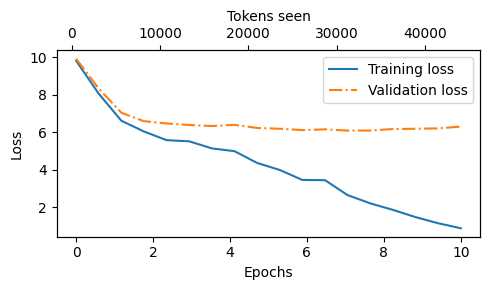

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 에포크에 대한 훈련 손실과 검증 손실의 그래프를 그립니다.
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # 처리한 토큰 수에 대한 두 번째 x 축을 만듭니다.
    ax2 = ax1.twiny()  # y 축을 공유하는 두 번째 x 축을 만듭니다.
    ax2.plot(tokens_seen, train_losses, alpha=0)  # 눈금을 정렬하기 위해 투명한 그래프를 만듭니다.
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))

plot_losses(epochs_tensor, track_token_seen, train_losses, val_losses)

3. 그래프 분석
    - 훈련 손실과 검증 손실은 모두 첫 번째 에포크 부터 향상되기 시작한다.
    - 위 결과를 보면 모델이 처음에는 이해할 수 없는 단어를 생성하지만 마지막으로 갈수록 문법적으로 어느 정도 정확한 문장을 생성합니다.
    - 두 번째 에포크를 지나면서 두 손실이 벌어지기 시작한다.
    - 검증 손실이, 훈련 손실보다 크다는 것은 모델이 훈련 데이터에 과적합되고 있음을 나타낸다.
        - 매우 작은 훈련 세트를 사용하고 모델을 여러 에포크에서 훈련하고 있기 때문에 과대적합이 일어납니다
        - "The Verdict" 텍스트 팩에서 모델이 생성한 텍스트 "quite insensible to the irony"와 같은 구문을 그대로 기억하고 있음을 알 수 있다.
    - 여기서는 교육적인 목적을 위해 LLM을 훈련합니다. 모델이 일관된 텍스트를 생성하는 방법을 학습할 수 있는지 확인하는 것이 주요 목적입니다.
    - 대량의 고가 하드웨어에서 몇 주 또는 몇 달 동안 이런 모델을 훈련하는 대신에 나중에 사전 훈련된 가중치를 로드하여 사용하겠습니다.

## Chapter 3 LLM 무작위성을 제어하기 위한 디코딩 전략 <a class="anchor" id="chapter3"></a>
1. 테스트를 위한 기존 generate_text_simple 설정 복습
    - 사전 훈련된 GPT 모델을 로드하고 텍스트를 생성하는 간단한 함수를 구현한다.
    - generate_text_simple 함수는 다음 토큰을 예측하기 위해 소프트맥스 확률 분포에서 가장 높은 값을 선택하는 그리디 디코딩 방식을 사용한다.


In [26]:
# 작은 모델을 추론할 때는 GPU보다 CPU가 더 효율적일 수 있습니다.
model.to('cpu')

# 드롭아웃과 같은 랜덤한 구성요소를 비활성화합니다.
model.eval()

# GTPModel의 객체를(model)를 generate_text_simple 함수에 전달하여 한 번에 하나의 토큰씩 텍스트를 생성합니다.
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

# 매 생성 단계마다 토큰이 선택된다.
#   - argmax 디코딩 전략을 사용하여 각 단계에서 가장 높은 확률을 갖는 토큰을 선택
#   - 동일한 입력에 대해 항상 동일한 출력을 생성
print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




2. 더 독창적인 텍스트를 생성하기 위한 텍스트 생성 전략 또는 디코딩 전략
    - torch.argmax를 사용해 항상 가장 높은 확률을 가진 토큰을 선택하는 방법을 그리디 디코딩(greedy decoding)이라고 한다.
    - 다양성이 더 높은 텍스트를 생성하기 위해 argmax 대신 확률 분포에서 샘플링하는 함수로 교체할 수 있다.

3. 확률적 샘플링을 위해 multinonmial을 사용하면 LLM이 "forward"외에 "closer,toward"를 선택할 수도있다.

In [27]:
# 확률적 샘플링을 위한 구체적인 예시를 위한 작은 어휘 사전
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}

# 어휘 사전의 역방향 매핑 생성
inverse_vocab = {v: k for k, v in vocab.items()}

# LLM 시작 문맥으로 "every effort moves you"를 받고 다음과 같은 로짓을 생성했다고 가정
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

# generate_text_simple 함수는 로짓을 소프트맥스 함수에 통과시켜 확률 분포를 얻은 다음,
# argmax를 사용하여 가장 높은 확률을 갖는 토큰을 선택한다.
probas = torch.softmax(next_token_logits, dim=-1)
next_token_id = torch.argmax(probas).item()
print(f"그리디 디코딩으로 선택된 토큰 ID: {next_token_id} ('{inverse_vocab[next_token_id]}')")

그리디 디코딩으로 선택된 토큰 ID: 3 ('forward')


In [28]:
# 확률적 샘플링을 위해 aragmax 대신 확률 분포에서 샘플링하는 함수 multinonmial을 사용
torch.manual_seed(123)  # 재현성을 위해 시드 설정
next_token_id = torch.multinomial(probas, num_samples=1).item()

# 확률적 샘플링이지만 이 예시에서는 동일한 토큰이 선택된다.
#   - "forward"가 가장 가능성이 높은 토큰이기 때문
print(f"확률적 샘플링으로 선택된 토큰 ID: {next_token_id} ('{inverse_vocab[next_token_id]}')")

확률적 샘플링으로 선택된 토큰 ID: 3 ('forward')


In [29]:
# 확률적 샘플링 1,000번 실행
def print_sample_tokens(probas):
    torch.manual_seed(123)  # 재현성을 위해 시드 설정
    sample = [torch.multinomial(probas, num_samples=1).item() for _ in range(1000)]
    # 샘플링된 토큰 ID의 빈도 수 계산
    #   - 각 토큰 ID의 발생 빈도를 세기 위해 torch.bincount 사용
    #   - 결과는 각 토큰 ID의 발생 횟수를 포함하는 텐서
    sample_ids = torch.bincount(torch.tensor(sample))
    
    # 각 토큰 ID와 해당 토큰이 선택된 횟수를 출력
    for token_id, count in enumerate(sample_ids):
        print(f"토큰 ID {token_id} ('{inverse_vocab[token_id]}')가 선택된 횟수: {count.item()}")
        
print_sample_tokens(probas)

토큰 ID 0 ('closer')가 선택된 횟수: 73
토큰 ID 1 ('every')가 선택된 횟수: 0
토큰 ID 2 ('effort')가 선택된 횟수: 0
토큰 ID 3 ('forward')가 선택된 횟수: 582
토큰 ID 4 ('inches')가 선택된 횟수: 2
토큰 ID 5 ('moves')가 선택된 횟수: 0
토큰 ID 6 ('pizza')가 선택된 횟수: 0
토큰 ID 7 ('toward')가 선택된 횟수: 343


4. 온도 스케일링(temperature scaling)을 통해 선택과정을 더 제어할 수 있다.
    - 0보다 더 큰수로 로짓을 나눈다.
    - 온도가 1보다 크면 확률 분포가 평탄해져서 덜 확실한 토큰이 선택될 가능성이 높아진다.
    - 온도가 1보다 작으면 확률 분포가 뾰족해져서 더 확실한 토큰이 선택될 가능성이 높아진다.
    - 문법적으로 잘못되거나 완전히 말이 안되는 출력을 만들 수 있다

In [30]:
def sofmax_with_temperature(logits, temperature):
    # 온도 스케일링을 적용하여 로짓을 조정
    scaled_logits = logits / temperature
    # 조정된 로짓에 소프트맥스 함수 적용
    probas = torch.softmax(scaled_logits, dim=-1)
    return probas

5. 온도 1은 로짓을 1로 나눈 후 소프트맥스 함수에 전달하여 확률점수를 계산
   - 스케일링을 하지 않은 것과 동일하다.

6. 온도 0.1은 확률분포를 뾰족하게 만들어 가장 확실한 토큰이 선택될 가능성을 높인다.

7. 온도 5는 확률분포를 평탄하게 만들어 덜 확실한 토큰이 선택될 가능성을 높인다.
   - 4%의 확률로 "pizza" 토큰이 선택된다.

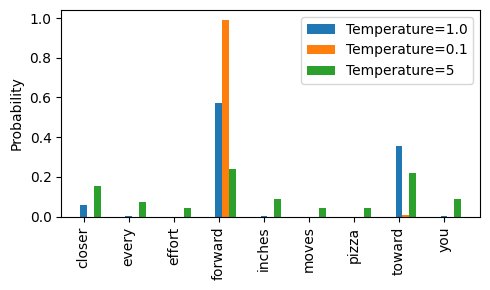

In [31]:
temperatures = [1.0, 0.1, 5] # 원본, 낮은 온도, 높은 온도

# 온도 스케일링이 적용된 확률 분포 계산
scaled_probas = [sofmax_with_temperature(next_token_logits, temp) for temp in temperatures]

x = torch.arange(len(vocab))  # x 축 값 (토큰 ID)
bar_width = 0.15          # 막대 너비
fig, ax = plt.subplots(figsize=(5, 3))

# 각 온도에 대해 막대 그래프를 그림
for i, temp in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], width=bar_width, label=f'Temperature={temp}')
    
ax.set_ylabel('Probability')
ax.set_xticks(x)
# x 축 레이블 설정
#   - rotation=90: 레이블을 90도 회전시켜 세로로 표시
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
# 연습문제 5.1
#   - 온도 스케일링이 적용된 소프트맥스 점수 및 샘플링 확률
#   - pizza 토큰의 선택 확률이 온도에 따라 어떻게 변하는지 관찰

temperatures = [1.0, 0.1, 5] # 원본, 낮은 온도, 높은 온도

# 온도 스케일링이 적용된 확률 분포 계산
scaled_probas = [sofmax_with_temperature(next_token_logits, temp) for temp in temperatures]

for i, probas in enumerate(scaled_probas):
    print("\n\n온도:", temperatures[i])
    print_sample_tokens(probas)



온도: 1.0
토큰 ID 0 ('closer')가 선택된 횟수: 73
토큰 ID 1 ('every')가 선택된 횟수: 0
토큰 ID 2 ('effort')가 선택된 횟수: 0
토큰 ID 3 ('forward')가 선택된 횟수: 582
토큰 ID 4 ('inches')가 선택된 횟수: 2
토큰 ID 5 ('moves')가 선택된 횟수: 0
토큰 ID 6 ('pizza')가 선택된 횟수: 0
토큰 ID 7 ('toward')가 선택된 횟수: 343


온도: 0.1
토큰 ID 0 ('closer')가 선택된 횟수: 0
토큰 ID 1 ('every')가 선택된 횟수: 0
토큰 ID 2 ('effort')가 선택된 횟수: 0
토큰 ID 3 ('forward')가 선택된 횟수: 985
토큰 ID 4 ('inches')가 선택된 횟수: 0
토큰 ID 5 ('moves')가 선택된 횟수: 0
토큰 ID 6 ('pizza')가 선택된 횟수: 0
토큰 ID 7 ('toward')가 선택된 횟수: 15


온도: 5
토큰 ID 0 ('closer')가 선택된 횟수: 165
토큰 ID 1 ('every')가 선택된 횟수: 75
토큰 ID 2 ('effort')가 선택된 횟수: 42
토큰 ID 3 ('forward')가 선택된 횟수: 239
토큰 ID 4 ('inches')가 선택된 횟수: 71
토큰 ID 5 ('moves')가 선택된 횟수: 46
토큰 ID 6 ('pizza')가 선택된 횟수: 32
토큰 ID 7 ('toward')가 선택된 횟수: 227
토큰 ID 8 ('you')가 선택된 횟수: 103


8. 탑-k 샘플링(top-k sampling)
   - 확률적 샘플링과 온도 스케일링을 결합한 방법이다.
   - 상위 k개의 토큰만 고려하고 나머지 토큰은 무시한다.
   - k 값을 조정하여 생성된 텍스트의 다양성을 제어할 수 있다.
   - k 값이 작을수록 모델은 더 확실한 토큰을 선택하게 되어 덜 다양해진다.
   - k 값이 클수록 모델은 더 다양한 토큰을 선택하게 되어 다양성이 높아진다.
   - 가장 높은 로짓을 가지 는 상위 k개의 토큰에 초점을 맞추고 소프트맥스 함수 적용 전에 모든 토큰을 음의 무한데로 마스킹한다.

      ![탑-k](image/05-03-topk2.png)

In [33]:
#top-K 구현
top_k = 3
# 상위 k개의 로짓과 인덱스 추출
#   - 다음 토큰을 선택하기 위해 상위 k개의 후보를 찾는다.
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("상위 k개의 로짓:", top_logits)
print("상위 k개의 인덱스:", top_pos)

# top-k 토큰 중 가장 마지막 토큰보다 작은 로짓 값을 음의 무한대로 설정
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print("top-k 필터링 후의 로짓:", new_logits)

# 소프트맥스 함수를 사용하여 확률 분포 계산
top_probas = torch.softmax(new_logits, dim=-1)
print("top-k 필터링 후의 확률 분포:", top_probas)

상위 k개의 로짓: tensor([6.7500, 6.2800, 4.5100])
상위 k개의 인덱스: tensor([3, 7, 0])
top-k 필터링 후의 로짓: tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
top-k 필터링 후의 확률 분포: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [34]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    #print("idx:", idx)
    #print("max_new_tokens:", max_new_tokens)
    #print("context_size:", context_size)

    # for 루프는 이전과 동일합니다. 로짓을 받아 마지막 타임 스텝만 사용합니다.
    for _ in range(max_new_tokens):
        # 현재 시퀀스의 마지막 context_size 토큰을 모델에 입력으로 제공합니다.
        idx_cond = idx[:, -context_size:]
     #   print("idx_cond:", idx_cond)
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # 탑-k 샘플링으로 로짓을 필터링합니다.
        if top_k is not None:
            # 탑-k 값만 유지합니다.
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # 온도 스케일링을 적용합니다.
        if temperature > 0.0:
            logits = logits / temperature

            # (책에 없음): mps 장치에서 동일한 결과를 얻기 위해 수치 안정성을 위한 팁
            # 소프트맥스 전에 행의 최댓값을 뺍니다.
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # 소프트맥스 함수를 적용하여 확률을 얻습니다.
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # 분포에서 샘플링합니다.
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # 온도 스케일링을 사용하지 않는 경우 이전처럼 그리디 샘플링을 사용해 다음 토큰을 선택합니다.
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # eos_id가 지정되어 있고 EoS 토큰을 만나면 생성을 중단합니다.
            break

        # 이전과 동일하게 샘플링된 인덱스를 현재 시퀀스 뒤에 추가합니다.
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [35]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("출력 텍스트 (top-k 샘플링):\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트 (top-k 샘플링):
 Every effort moves you stand to work on surprise, one of his glory, or by his painting


In [36]:
# 연습문제 5.2: 다양한 온도 및 top-k 설정
#   - 온도 및 top-k 설정 모두 개별 LLM에 따라 조정해야 합니다 (원하는 출력을 생성할 때까지 시행착오 과정).
#   - 바람직한 결과는 애플리케이션마다 다릅니다.
#   - 낮은 top-k 및 온도는 교육 콘텐츠, 기술 문서 또는 질문 응답, 데이터 분석, 코드 생성 등을 작성할 때 바람직한 덜 무작위적인 결과를 생성합니다.
#   - 높은 top-k 및 온도는 브레인스토밍 작업, 창의적인 글쓰기 등에 더 바람직한 더 다양하고 무작위적인 출력을 생성합니다.

In [45]:
# 연습문제 5.3: 디코딩 함수의 결정론적인 동작
#   - temperature=0.0으로 설정;
#   - top_k=1로 설정.

torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=1,
    temperature=0.0
)

print("출력 텍스트 (top-k 샘플링):\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트 (top-k 샘플링):
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted


## Chapter 4 파이토치로 모델 로드하고 저장하기 <a class="anchor" id="chapter4"></a>
1. 파이토치로 모델 저장하고 로드하기
    - 파이토치는 모델의 가중치를 저장하고 로드하는 간단한 방법을 제공한다.
    - torch.save() 함수를 사용하여 모델의 state_dict를 파일에 저장할 수 있다.
    - torch.load() 함수를 사용하여 저장된 state_dict를 파일에서 로드할 수 있다.
    - 로드된 state_dict를 모델에 적용하려면 model.load_state_dict() 메서드를 사용한다.

2. AdamW와 같은 적응형 옵티마이져는 모델 가중치마다 추가 파라미터를 저장한다.
    - 과거 데이터를 사용하여 각 모델 파라미터의 학습률을 동적으로 저장한다.
    - 데이터가 없으면 옵티마이저가 초기화되고 모델이 최적점이 아닌 곳으로 수렴하거나 수렴에 실패할 수 있다.
    - torch.save를 통해 모델과 옵티마이저의 state_dict를 모두 저장할 수 있다.

In [38]:
# 모델 저장
#   - .pth 확장자를 관례적으로 사용한다.
torch.save(model.state_dict(), 'model.pth')

In [40]:
# 세로운 모델에 가중치 로드
model2 = GPTModel(GPT_CONFIG_124M)
state_dict = torch.load('model.pth', map_location=device)
model2.load_state_dict(state_dict)
model2.to(device)
model2.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [41]:
torch.save({"model_state_dict": model.state_dict(),
           "optimizer_state_dict": optimizer.state_dict()}, 'model_and_optimizer.pth')

In [42]:
checkpoint = torch.load('model_and_optimizer.pth', map_location=device)
model3 = GPTModel(GPT_CONFIG_124M)
model3.load_state_dict(checkpoint['model_state_dict'])
optimizer2 = torch.optim.AdamW(model3.parameters(), lr=0.0004, weight_decay=0.1)
optimizer2.load_state_dict(checkpoint['optimizer_state_dict'])
model3.to(device)
model3.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [47]:
# 연습문제 5.4
import tiktoken
import torch
from previous_chapters import GPTModel


GPT_CONFIG_124M = {
    "vocab_size": 50257,   # 어휘 크기
    "context_length": 256, # 짧아진 컨텍스트 길이 (원래: 1024)
    "emb_dim": 768,        # 임베딩 차원
    "n_heads": 12,         # 어텐션 헤드 수
    "n_layers": 12,        # 층 수
    "drop_rate": 0.1,      # 드롭아웃 비율
    "qkv_bias": False      # 쿼리-키-값 편향
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = tiktoken.get_encoding("gpt2")

checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

In [48]:
import os
import urllib.request
from previous_chapters import create_dataloader_v1


file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()


# 훈련/검증 비율
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [49]:
# 깃허브에서 gpt_train.py 파일을 다운로드합니다.
!wget https://bit.ly/4mODn07 -O gpt_train.py

--2025-10-21 15:09:47--  https://bit.ly/4mODn07
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/gpt_train.py [following]
--2025-10-21 15:09:48--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/gpt_train.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8360 (8.2K) [text/plain]
Saving to: ‘gpt_train.py’

gpt_train.py        100%[===================>]   8.16K  --.-KB/s    in 0s      

2025-10-21 15:09:48 (74.6 MB/s) - ‘gpt_train.py’ saved [8360/8360]



In [50]:
from gpt_train import train_model_simple

num_epochs = 1
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 0.662, Val loss 6.366
Ep 1 (Step 000005): Train loss 0.470, Val loss 6.439
Every effort moves you?" "Oh, my hostess was "interesting": on that point I could have given Miss Croft the fullest reassurance. It was just because she was _not_ interesting--if I saw that, my eye fell on a small picture


## Chapter 5 오픈AI에서 사전 훈련된 가중치 로드하기 <a class="anchor" id="chapter5"></a>
1. 오픈 AI는 GPT-2 모델의 가중치를 공개적으로 제공하기 때문에 대규모 말뭉치에서 모델을 재훈련 할 필요없다.

In [53]:
from importlib.metadata import version

pkgs = ["torch"]
for p in pkgs:
    print(f"{p} version: {version(p)}")

torch version: 2.8.0


In [54]:
BASE_CONFIG = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0,       # Dropout rate
    "qkv_bias": True        # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}


CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [55]:
file_name = "gpt2-small-124M.pth"

In [56]:
import os
import urllib.request

url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"

if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)
    print(f"Downloaded to {file_name}")

In [58]:
import torch
#from llms_from_scratch.ch04 import GPTModel
# For llms_from_scratch installation instructions, see:
# https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg


gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load(file_name, weights_only=True))
gpt.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt.to(device);

In [59]:
import tiktoken

torch.manual_seed(123)

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate(
    model=gpt.to(device),
    idx=text_to_token_ids("Every effort moves", tokenizer).to(device),
    max_new_tokens=30,
    context_size=BASE_CONFIG["context_length"],
    top_k=1,
    temperature=1.0
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves forward, but it's not enough.

"I'm not going to sit here and say, 'I'm not going to do this,'


In [60]:
print("텐서플로 버전:", version("tensorflow"))
print("tqdm 버전:", version("tqdm"))

텐서플로 버전: 2.19.0
tqdm 버전: 4.67.1


In [61]:
!wget https://bit.ly/4kSEn1v -O gpt_download.py

--2025-10-21 15:22:49--  https://bit.ly/4kSEn1v
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/gpt_download.py [following]
--2025-10-21 15:22:49--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/gpt_download.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6333 (6.2K) [text/plain]
Saving to: ‘gpt_download.py’

gpt_download.py     100%[===================>]   6.18K  --.-KB/s    in 0s      

2025-10-21 15:22:49 (59.0 MB/s) - ‘gpt_download.py’ saved [6333/63

In [62]:
from gpt_download import download_and_load_gpt2

2025-10-21 15:23:03.694659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761027783.761659     982 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761027783.781061     982 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761027783.923054     982 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761027783.923076     982 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761027783.923078     982 computation_placer.cc:177] computation placer alr

In [63]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 77.7kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 926kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 88.5kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [01:58<00:00, 4.20MiB/s]  
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 6.04MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 586kiB/s] 
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 571kiB/s] 


In [64]:
print("설정:", settings)
print("파라미터 딕셔너리 키:", params.keys())

설정: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
파라미터 딕셔너리 키: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [65]:
print(params["wte"])
print("토큰 임베딩 가중치 텐서의 차원:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
토큰 임베딩 가중치 텐서의 차원: (50257, 768)


In [66]:
# 딕셔너리로 모델 설정을 저장합니다.
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# 기본 설정을 특정 값으로 업데이트합니다.
model_name = "gpt2-small (124M)"  # 모델 이름
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [67]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"크기가 다릅니다. left: {left.shape}, right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [68]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


load_weights_into_gpt(gpt, params)
gpt.to(device);

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))


출력 텍스트:
 Every effort moves you as far as the hand can go until the end of your turn unless something interrupts your control flow. As you may observe I
